# Baseline Modeling

Systematic comparison of band gap prediction models across three axes:

| Axis | Options |
|---|---|
| Feature set | Composition (133), Site (36), DOS (226) |
| Training scope | alloys-only (pure phase as features), combined (alloys + pure phases) |
| Approach | Single regression, Two-stage (classify metal/semiconductor → regress Eg) |

**What each comparison reveals:**
- **Composition vs Site**: How does per-site elemental properties compare to stoichiometry-weighted statistics in predicting band gaps?
- **Site vs DOS**: How important is alloy DFT band structure information compared to elemental proxies alone?
- **Alloys-only vs Alloy+Pure phases**: do pure phase endpoints help the model anchor its predictions?
- **Single vs two-stage**: Are metal/insulator properties better handled by explicit classification?

**Use case map:**
- Composition = Use Case A (no DFT, composition averaged elemental proxies)
- Site = Use Case B-lite (no DFT, elemental proxies)
- DOS = Use Case C (requires alloy DFT, upper bound)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, f1_score, confusion_matrix,
)
from xgboost import XGBRegressor, XGBClassifier

In [2]:
comp_df = pd.read_parquet('composition_feature_matrix.parquet')
site_df = pd.read_parquet('site_feature_matrix.parquet')
dos_df  = pd.read_parquet('dos_feature_matrix.parquet')
dos_endpoint_df = pd.read_parquet('dos_endpoint_feature_matrix.parquet')

# x_frac is NaN for the 527 pure phases in all matrices (feature engineering imputed it
# only in full_feat_df). Impute to 0.0 here: pure phases have no B-site mixing.
for df in (comp_df, site_df, dos_df, dos_endpoint_df):
    df['x_frac'] = df['x_frac'].fillna(0.0)

# Feature column selectors — everything that is not an identifier, site label, or target.
# x_frac is intentionally included: it is always known (part of the alloy specification)
# and carries direct physical meaning (B-site mixing fraction).
NON_FEAT = {'formula', 'alloy_id', 'A1', 'A2', 'B1', 'B2', 'X', 'is_alloy', 'Eg', 'dHf', 'dHd', 'direct'}

COMP_COLS = [c for c in comp_df.columns if c not in NON_FEAT]  # 132 MAGPIE + x_frac
SITE_COLS = [c for c in site_df.columns if c not in NON_FEAT]  # 35 site props + x_frac
DOS_COLS  = [c for c in dos_df.columns  if c not in NON_FEAT]  # 225 DOS features + x_frac
DOS_ENDPOINT_COLS = [c for c in dos_endpoint_df.columns if c not in NON_FEAT]  # 12 endpoint features + x_frac

print(f'Composition features : {len(COMP_COLS)}')
print(f'Site features        : {len(SITE_COLS)}')
print(f'DOS features         : {len(DOS_COLS)}')
print(f'DOS Endpoint features: {len(DOS_ENDPOINT_COLS)}')
print(f'\nRows total   : {len(comp_df)}')
print(f'Alloys       : {comp_df.is_alloy.sum()}')
print(f'Pure phases  : {(~comp_df.is_alloy).sum()}')
print(f'Metallic     : {(comp_df.Eg == 0).sum()} ({(comp_df.Eg == 0).mean():.1%})')

Composition features : 133
Site features        : 36
DOS features         : 226
DOS Endpoint features: 73

Rows total   : 6519
Alloys       : 5992
Pure phases  : 527
Metallic     : 2049 (31.4%)


## 1. Train / Test Split (Alloy-Group-Based)

**Improvement: Chemistry-aware split at the alloy group level** — Previously used random 80/20 stratified on metallic/semiconductor. Now: split at the **unique formula** level so all rows of a material stay together.

**Why this matters:**
- **Old approach**: Test set could include Eg values at x=0.5 for alloys seen at x=0.25 in training. Model learns to interpolate within known chemistries.
- **New approach**: Test set contains completely unseen material formulas. Model must generalize to new chemistries, not just new mixing fractions. This is the true test of chemistry understanding.

**Implementation:**
1. Identify all unique formulas in the dataset
2. Split unique formulas at ~80/20
3. All rows (both alloys and pure phases) assigned by formula membership
4. Same `random_state=42` ensures consistent splits across all experiments for fair feature comparison

In [3]:
def make_split(df, test_size=0.2, random_state=42):
    """
    Alloy-group-based train/test split using alloy_id.

    Alloys (alloy_id is not null): split at the alloy_id level so all compositions
    (x=0.25, 0.50, 0.75) of the same alloy series stay in the same partition.
    Tests generalization to unseen alloy chemistries — not just unseen mixing fractions
    of chemistries already seen at other x values.

    Pure phases (alloy_id is null): no alloy group to respect, so split independently
    by formula at the same ratio.
    """
    rng = np.random.RandomState(random_state)

    # --- Alloys: group by alloy_id ---
    alloy_mask = df['alloy_id'].notna()

    unique_ids = df.loc[alloy_mask, 'alloy_id'].unique()
    rng.shuffle(unique_ids)
    split_idx  = int(len(unique_ids) * (1 - test_size))
    train_ids  = set(unique_ids[:split_idx])

    alloy_train = alloy_mask & df['alloy_id'].isin(train_ids)
    alloy_test  = alloy_mask & ~df['alloy_id'].isin(train_ids)

    # --- Pure phases: split independently by formula ---
    pure_mask = ~alloy_mask
    pure_train = pd.Series(False, index=df.index)
    pure_test  = pd.Series(False, index=df.index)

    if pure_mask.sum() > 0:
        unique_pure = df.loc[pure_mask, 'formula'].unique()
        rng.shuffle(unique_pure)
        split_pure  = int(len(unique_pure) * (1 - test_size))
        train_pure  = set(unique_pure[:split_pure])
        pure_train  = pure_mask & df['formula'].isin(train_pure)
        pure_test   = pure_mask & ~df['formula'].isin(train_pure)

    train = df.loc[alloy_train | pure_train].reset_index(drop=True)
    test  = df.loc[alloy_test  | pure_test ].reset_index(drop=True)
    return train, test


SCOPES = {
    'alloys_only': lambda df: df[df['is_alloy']].copy().reset_index(drop=True),
    'combined':    lambda df: df.copy(),
}

# Verify scope sizes
for scope_name, scope_fn in SCOPES.items():
    scoped = scope_fn(comp_df)
    tr, te = make_split(scoped)
    metal_te = (te['Eg'] == 0).mean()
    print(f'{scope_name:12s}: {len(tr)} train / {len(te)} test | metallic in test: {metal_te:.1%}')

alloys_only : 4789 train / 1203 test | metallic in test: 32.8%
combined    : 5210 train / 1309 test | metallic in test: 32.0%


In [4]:
# Verify alloy-group split: no alloy_id should appear in both train and test
print('=== Alloy-Group-Based Split Verification ===\n')
for scope_name, scope_fn in SCOPES.items():
    scoped = scope_fn(comp_df)
    tr, te = make_split(scoped)

    # Alloy group counts
    n_train_groups = tr['alloy_id'].dropna().nunique()
    n_test_groups  = te['alloy_id'].dropna().nunique()

    # Check for leakage: any alloy_id present in both partitions
    train_ids = set(tr['alloy_id'].dropna().unique())
    test_ids  = set(te['alloy_id'].dropna().unique())
    leaked    = train_ids & test_ids

    print(f'{scope_name}:')
    print(f'  Alloy groups : {n_train_groups} train / {n_test_groups} test')
    print(f'  Rows         : {len(tr)} train / {len(te)} test')
    print(f'  Split ratio  : {len(tr)/(len(tr)+len(te)):.1%} train / {len(te)/(len(tr)+len(te)):.1%} test')
    print(f'  Metallic in test: {(te["Eg"] == 0).mean():.1%}')
    print(f'  alloy_id leakage: {len(leaked)} groups  {"✓ CLEAN" if not leaked else "✗ LEAK DETECTED " + str(leaked)}')
    print()

=== Alloy-Group-Based Split Verification ===

alloys_only:
  Alloy groups : 1629 train / 408 test
  Rows         : 4789 train / 1203 test
  Split ratio  : 79.9% train / 20.1% test
  Metallic in test: 32.8%
  alloy_id leakage: 0 groups  ✓ CLEAN

combined:
  Alloy groups : 1629 train / 408 test
  Rows         : 5210 train / 1309 test
  Split ratio  : 79.9% train / 20.1% test
  Metallic in test: 32.0%
  alloy_id leakage: 0 groups  ✓ CLEAN



In [5]:
def compute_metrics(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    return mae, rmse, r2

## 2. Preprocessing

**Linear models (Ridge, Lasso):**  
`SimpleImputer(median)` → `StandardScaler`. Applied to Composition features only — these have no NaN so imputation is a no-op, but the pipeline is kept consistent for reuse.

**Why not apply linear models to Site or DOS?**  
- Site features have ~46% NaN in A2 columns (single-A-site compounds) and ~8% in B2/x_frac (pure phases). Median imputation of A2 properties assigns the average A2 element to all single-A-site compounds — physically wrong and likely to confuse a linear model that treats feature values as ordinal.
- DOS features have ~100% rows with at least one NaN (element-specific columns are NaN when that element is absent). Imputing ~200 columns per row muddies the sparse signal.
- **Tree models handle these NaN natively**: at each split, XGBoost routes NaN samples to a learned default branch, so missing A2 properties or absent-element DOS columns are informative rather than imputed away.

**`orb_idx` columns in DOS:** integer-encoded orbital character (0=s, 1=p, 2=d). Treated as numeric by XGBoost (tree splits on thresholds, so ordinal interpretation is irrelevant). A proper linear model treatment would require one-hot encoding; that is deferred.

In [6]:
def make_linear_pipeline():
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
    ])

# Shared XGBoost hyperparameters — reasonable defaults for a baseline.
# These are not tuned; hyperparameter optimisation is a future step.
# Regressor. More trees and deeper depth to capture the more complex regression patterns in the larger dataset.
XGB_REG = dict(
    n_estimators=500, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1, verbosity=0,
)
# Classifier. Fewer trees and shallower depth to reduce overfitting on the smaller classification dataset.
XGB_CLF = dict(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    random_state=42, n_jobs=-1, verbosity=0, eval_metric='logloss',
)

# Log-spaced alpha grid for RidgeCV / LassoCV cross-validated regularisation search.
# cv=5 folds are used by LassoCV; RidgeCV uses efficient GCV (generalised cross-validation).
ALPHA_GRID = np.logspace(-3, 3, 13)

## 3. Single Regression

All rows (metals + semiconductors) in the training split feed directly into the model. Eg=0 metals are just another training point. The model must learn both the hard floor at 0 and the continuous gap distribution above it from the same parameters.

Predictions and true values are stored in `predictions` for later plotting.

In [7]:
results      = []   # list of metric dicts
predictions  = {}   # (feat_name, scope, approach, model) → (y_true_test, y_pred_test, is_alloy_test)


def run_single(df, feat_cols, feat_name, scope_name, model_name, model, is_linear=False):
    train, test = make_split(df)
    X_tr = train[feat_cols].values;  y_tr = train['Eg'].values
    X_te = test[feat_cols].values;   y_te = test['Eg'].values

    if is_linear:
        pipe = make_linear_pipeline()
        X_tr = pipe.fit_transform(X_tr)
        X_te = pipe.transform(X_te)

    model.fit(X_tr, y_tr)
    y_pred_tr = model.predict(X_tr)
    y_pred_te = model.predict(X_te)

    mae_tr, rmse_tr, r2_tr = compute_metrics(y_tr, y_pred_tr)
    mae_te, rmse_te, r2_te = compute_metrics(y_te, y_pred_te)

    key = (feat_name, scope_name, 'single_regression', model_name)
    predictions[key] = (y_te, y_pred_te, test['is_alloy'].values)

    return dict(
        feature_set=feat_name, scope=scope_name,
        approach='single_regression', model=model_name,
        train_MAE=mae_tr, train_RMSE=rmse_tr, train_R2=r2_tr,
        test_MAE=mae_te,  test_RMSE=rmse_te,  test_R2=r2_te,
        n_train=len(y_tr), n_test=len(y_te),
        clf_accuracy=None, clf_F1_metal=None,
    )

In [8]:
FEATURE_SETS = [
    ('Composition', comp_df, COMP_COLS),
    ('Site',        site_df, SITE_COLS),
    ('DOS',         dos_df,  DOS_COLS),
    ('DOS Endpoint', dos_endpoint_df, DOS_ENDPOINT_COLS),
]

for feat_name, df, feat_cols in FEATURE_SETS:
    for scope_name, scope_fn in SCOPES.items():
        scoped = scope_fn(df)

        # XGBoost — all feature sets
        r = run_single(scoped, feat_cols, feat_name, scope_name,
                       'XGBoost', XGBRegressor(**XGB_REG))
        results.append(r)
        print(f'{feat_name:12s} | {scope_name:12s} | XGBoost   '
              f'test MAE={r["test_MAE"]:.4f}  R²={r["test_R2"]:.3f}  '
              f'(train MAE={r["train_MAE"]:.4f})')

        # Ridge and Lasso — Composition only (zero NaN, full numeric)
        if feat_name == 'Composition':
            r = run_single(scoped, feat_cols, feat_name, scope_name,
                           'Ridge', RidgeCV(alphas=ALPHA_GRID), is_linear=True)
            results.append(r)
            print(f'{feat_name:12s} | {scope_name:12s} | Ridge     '
                  f'test MAE={r["test_MAE"]:.4f}  R²={r["test_R2"]:.3f}  '
                  f'(train MAE={r["train_MAE"]:.4f})')

            r = run_single(scoped, feat_cols, feat_name, scope_name,
                           'Lasso', LassoCV(alphas=ALPHA_GRID, max_iter=5000, n_jobs=-1),
                           is_linear=True)
            results.append(r)
            print(f'{feat_name:12s} | {scope_name:12s} | Lasso     '
                  f'test MAE={r["test_MAE"]:.4f}  R²={r["test_R2"]:.3f}  '
                  f'(train MAE={r["train_MAE"]:.4f})')

Composition  | alloys_only  | XGBoost   test MAE=0.0592  R²=0.996  (train MAE=0.0248)
Composition  | alloys_only  | Ridge     test MAE=0.3988  R²=0.892  (train MAE=0.3891)
Composition  | alloys_only  | Lasso     test MAE=0.4225  R²=0.882  (train MAE=0.4136)
Composition  | combined     | XGBoost   test MAE=0.0638  R²=0.996  (train MAE=0.0281)
Composition  | combined     | Ridge     test MAE=0.4181  R²=0.893  (train MAE=0.4061)
Composition  | combined     | Lasso     test MAE=0.4331  R²=0.885  (train MAE=0.4188)
Site         | alloys_only  | XGBoost   test MAE=0.0570  R²=0.997  (train MAE=0.0403)
Site         | combined     | XGBoost   test MAE=0.0629  R²=0.996  (train MAE=0.0437)
DOS          | alloys_only  | XGBoost   test MAE=0.1066  R²=0.988  (train MAE=0.0441)
DOS          | combined     | XGBoost   test MAE=0.1104  R²=0.988  (train MAE=0.0503)
DOS Endpoint | alloys_only  | XGBoost   test MAE=0.1479  R²=0.977  (train MAE=0.0526)
DOS Endpoint | combined     | XGBoost   test MAE=0.146

## 4. Two-Stage: Classify Metal/Semiconductor → Regress Eg

**Motivation:** Metallic compounds (Eg=0) and semiconductors (Eg>0) are physically distinct phases. A single regressor treats Eg=0 as a continuous prediction target, but metallicity is a qualitative property (a phase boundary, not just a small gap). If the metal/insulator transition boundary is hard to capture as a smooth function, separating classification from regression should improve both.

**Pipeline:**
1. **XGBClassifier** trained on full training set: predict `is_metal` (Eg==0).
2. **XGBRegressor** trained *only on true non-metals* in the training set (regressor never sees Eg=0 rows).
3. At test time: classifier routes each row → predicted metals get Eg=0, predicted non-metals go through the regressor.

**Error compounding:** A false-negative metal (semiconductor predicted as metal) gets Eg=0 instead of the true gap — large MAE contribution. A false-positive non-metal (metal predicted as semiconductor) gets a non-zero predicted gap. These errors are baked into the final test MAE, making the comparison directly interpretable.

The classifier is trained on **true** train labels, not predicted ones. The regressor is also trained on **true** train non-metals. The routing at test time is the only place predicted labels are used.

In [9]:
def run_two_stage(df, feat_cols, feat_name, scope_name):
    '''
    This function runs two models in sequence:
    1. Classifier (XGBClassifier) to first predict whether each sample is metallic (Eg=0) or semiconducting (Eg>0).
    2. Regressor (XGBRegressor) trained only on TRUE semiconductors
    '''
    train, test = make_split(df)
    X_tr = train[feat_cols].values;  y_tr = train['Eg'].values
    X_te = test[feat_cols].values;   y_te = test['Eg'].values

    metal_tr = (y_tr == 0).astype(int)  # 1 = metal, 0 = semiconductor
    metal_te = (y_te == 0).astype(int)

    # Stage 1: metal/semiconductor classifier
    clf = XGBClassifier(**XGB_CLF)
    clf.fit(X_tr, metal_tr) # training input: X_tr contains Eg values, metal_tr is binary indicating if an Eg is zero or non-zero
    pred_metal_tr = clf.predict(X_tr)
    pred_metal_te = clf.predict(X_te)

    clf_acc = accuracy_score(metal_te, pred_metal_te)
    # F1 score for the metal class: catches both missed metals and false-metal predictions
    clf_f1  = f1_score(metal_te, pred_metal_te)

    print(f'  Classifier — accuracy: {clf_acc:.3f}  F1(metal): {clf_f1:.3f}')
    cm = confusion_matrix(metal_te, pred_metal_te)
    print(f'  Confusion matrix (rows=true, cols=pred):  '
          f'TN={cm[0,0]} FP={cm[0,1]} FN={cm[1,0]} TP={cm[1,1]}')

    # Stage 2: regressor trained on true non-metals only
    sc_mask_tr = (metal_tr == 0)
    reg = XGBRegressor(**XGB_REG)
    reg.fit(X_tr[sc_mask_tr], y_tr[sc_mask_tr])

    # Test predictions routed by classifier
    y_pred_te = np.zeros(len(y_te))
    sc_pred_te = (pred_metal_te == 0)
    if sc_pred_te.sum() > 0:
        y_pred_te[sc_pred_te] = reg.predict(X_te[sc_pred_te])

    # Train predictions routed by classifier (for overfit diagnosis)
    y_pred_tr = np.zeros(len(y_tr))
    sc_pred_tr = (pred_metal_tr == 0)
    if sc_pred_tr.sum() > 0:
        y_pred_tr[sc_pred_tr] = reg.predict(X_tr[sc_pred_tr])

    mae_tr, rmse_tr, r2_tr = compute_metrics(y_tr, y_pred_tr)
    mae_te, rmse_te, r2_te = compute_metrics(y_te, y_pred_te)

    key = (feat_name, scope_name, 'two_stage', 'XGB_2stage')
    predictions[key] = (y_te, y_pred_te, test['is_alloy'].values)

    return dict(
        feature_set=feat_name, scope=scope_name,
        approach='two_stage', model='XGB_2stage',
        train_MAE=mae_tr, train_RMSE=rmse_tr, train_R2=r2_tr,
        test_MAE=mae_te,  test_RMSE=rmse_te,  test_R2=r2_te,
        n_train=len(y_tr), n_test=len(y_te),
        clf_accuracy=clf_acc, clf_F1_metal=clf_f1,
    )

In [10]:
for feat_name, df, feat_cols in FEATURE_SETS:
    for scope_name, scope_fn in SCOPES.items():
        scoped = scope_fn(df)
        print(f'{feat_name} | {scope_name}')
        r = run_two_stage(scoped, feat_cols, feat_name, scope_name)
        results.append(r)
        print(f'  Final     — test MAE={r["test_MAE"]:.4f}  R²={r["test_R2"]:.3f}  '
              f'(train MAE={r["train_MAE"]:.4f})')
        print()

Composition | alloys_only
  Classifier — accuracy: 0.940  F1(metal): 0.909
  Confusion matrix (rows=true, cols=pred):  TN=772 FP=36 FN=36 TP=359
  Final     — test MAE=0.0547  R²=0.996  (train MAE=0.0188)

Composition | combined
  Classifier — accuracy: 0.938  F1(metal): 0.903
  Confusion matrix (rows=true, cols=pred):  TN=850 FP=40 FN=41 TP=378
  Final     — test MAE=0.0595  R²=0.996  (train MAE=0.0214)

Site | alloys_only
  Classifier — accuracy: 0.937  F1(metal): 0.906
  Confusion matrix (rows=true, cols=pred):  TN=761 FP=47 FN=29 TP=366
  Final     — test MAE=0.0510  R²=0.997  (train MAE=0.0331)

Site | combined
  Classifier — accuracy: 0.937  F1(metal): 0.901
  Confusion matrix (rows=true, cols=pred):  TN=849 FP=41 FN=42 TP=377
  Final     — test MAE=0.0589  R²=0.996  (train MAE=0.0373)

DOS | alloys_only
  Classifier — accuracy: 0.946  F1(metal): 0.920
  Confusion matrix (rows=true, cols=pred):  TN=763 FP=45 FN=20 TP=375
  Final     — test MAE=0.0876  R²=0.991  (train MAE=0.0349)

## 5. Results

In [11]:
results_df = pd.DataFrame(results)

# --- Single regression ---
single = (
    results_df[results_df.approach == 'single_regression']
    [['feature_set', 'scope', 'model', 'train_MAE', 'test_MAE', 'test_RMSE', 'test_R2']]
    .sort_values(['feature_set', 'scope', 'model'])
    .reset_index(drop=True)
)
print('=== Single Regression ===')
display(single.round(4))

# --- Two-stage ---
two = (
    results_df[results_df.approach == 'two_stage']
    [['feature_set', 'scope', 'model', 'train_MAE', 'test_MAE', 'test_RMSE', 'test_R2',
      'clf_accuracy', 'clf_F1_metal']]
    .sort_values(['feature_set', 'scope'])
    .reset_index(drop=True)
)
print('\n=== Two-Stage ===')
display(two.round(4))

=== Single Regression ===


,feature_set,scope,model,train_MAE,test_MAE,test_RMSE,test_R2
0,Composition,alloys_only,Lasso,0.4136,0.4225,0.5474,0.8824
1,Composition,alloys_only,Ridge,0.3891,0.3988,0.5248,0.8919
2,Composition,alloys_only,XGBoost,0.0248,0.0592,0.0955,0.9964
3,Composition,combined,Lasso,0.4188,0.4331,0.5613,0.8852
4,Composition,combined,Ridge,0.4061,0.4181,0.5425,0.8927
5,Composition,combined,XGBoost,0.0281,0.0638,0.1035,0.9961
6,DOS,alloys_only,XGBoost,0.0441,0.1066,0.1746,0.9880
7,DOS,combined,XGBoost,0.0503,0.1104,0.1777,0.9885
8,DOS Endpoint,alloys_only,XGBoost,0.0526,0.1479,0.2411,0.9772
9,DOS Endpoint,combined,XGBoost,0.0552,0.1465,0.2364,0.9796



=== Two-Stage ===


,feature_set,scope,model,train_MAE,test_MAE,test_RMSE,test_R2,clf_accuracy,clf_F1_metal
0,Composition,alloys_only,XGB_2stage,0.0188,0.0547,0.0963,0.9964,0.9401,0.9089
1,Composition,combined,XGB_2stage,0.0214,0.0595,0.1022,0.9962,0.9381,0.9032
2,DOS,alloys_only,XGB_2stage,0.0349,0.0876,0.1538,0.9907,0.9460,0.9202
3,DOS,combined,XGB_2stage,0.0388,0.0927,0.1634,0.9903,0.9358,0.9023
4,DOS Endpoint,alloys_only,XGB_2stage,0.0409,0.1280,0.2293,0.9794,0.9036,0.8539
5,DOS Endpoint,combined,XGB_2stage,0.0434,0.1223,0.2239,0.9817,0.9060,0.8548
6,Site,alloys_only,XGB_2stage,0.0331,0.0510,0.0901,0.9968,0.9368,0.9059
7,Site,combined,XGB_2stage,0.0373,0.0589,0.1034,0.9961,0.9366,0.9008


In [12]:
# Ablation pivot: test MAE (eV) — one row per (feature_set, scope), one col per (approach, model)
print('=== Ablation Table: test MAE (eV) ===')
pivot = (
    results_df
    .assign(config=results_df.approach + ' / ' + results_df.model)
    .pivot_table(values='test_MAE', index=['feature_set','scope'], columns='config', aggfunc='first')
    .round(4)
)
display(pivot)

=== Ablation Table: test MAE (eV) ===


config                    single_regression / Lasso  \
feature_set  scope                                    
Composition  alloys_only                     0.4225   
             combined                        0.4331   
DOS          alloys_only                        NaN   
             combined                           NaN   
DOS Endpoint alloys_only                        NaN   
             combined                           NaN   
Site         alloys_only                        NaN   
             combined                           NaN   

config                    single_regression / Ridge  \
feature_set  scope                                    
Composition  alloys_only                     0.3988   
             combined                        0.4181   
DOS          alloys_only                        NaN   
             combined                           NaN   
DOS Endpoint alloys_only                        NaN   
             combined                           NaN   
Site         alloys_only                        NaN   
             combined                           NaN   

config                    single_regression / XGBoost  two_stage / XGB_2stage  
feature_set  scope                                                             
Composition  alloys_only                       0.0592                  0.0547  
             combined                          0.0638                  0.0595  
DOS          alloys_only                       0.1066                  0.0876  
             combined                          0.1104                  0.0927  
DOS Endpoint alloys_only                       0.1479                  0.1280  
             combined                          0.1465                  0.1223  
Site         alloys_only                       0.0570                  0.0510  
             combined                          0.0629                  0.0589

In [13]:
# Alloy vs pure phase MAE breakdown — combined scope only.
# Alloys_only scope has no pure phases so breakdown is not applicable there.
print('=== Test MAE breakdown: alloys vs pure phases (combined scope) ===\n')
print(f'{"Feature set":14s}  {"Approach":22s}  {"Alloy MAE":>10s}  {"Pure MAE":>10s}  {"n_alloy":>8s}  {"n_pure":>7s}')
print('-' * 80)

for feat_name, _, _ in FEATURE_SETS:
    for approach, model_name in [('single_regression', 'XGBoost'), ('two_stage', 'XGB_2stage')]:
        key = (feat_name, 'combined', approach, model_name)
        if key not in predictions:
            continue
        y_true, y_pred, is_alloy = predictions[key]
        is_pure = ~is_alloy
        if is_pure.sum() == 0:
            continue
        mae_alloy = mean_absolute_error(y_true[is_alloy], y_pred[is_alloy])
        mae_pure  = mean_absolute_error(y_true[is_pure],  y_pred[is_pure])
        label = f'XGBoost single' if approach == 'single_regression' else 'XGB two-stage'
        print(f'{feat_name:14s}  {label:22s}  {mae_alloy:10.4f}  {mae_pure:10.4f}  '
              f'{is_alloy.sum():8d}  {is_pure.sum():7d}')

=== Test MAE breakdown: alloys vs pure phases (combined scope) ===

Feature set     Approach                 Alloy MAE    Pure MAE   n_alloy   n_pure
--------------------------------------------------------------------------------
Composition     XGBoost single              0.0600      0.1072      1203      106
Composition     XGB two-stage               0.0560      0.0997      1203      106
Site            XGBoost single              0.0591      0.1055      1203      106
Site            XGB two-stage               0.0546      0.1084      1203      106
DOS             XGBoost single              0.1059      0.1623      1203      106
DOS             XGB two-stage               0.0881      0.1449      1203      106
DOS Endpoint    XGBoost single              0.1479      0.1312      1203      106
DOS Endpoint    XGB two-stage               0.1231      0.1133      1203      106


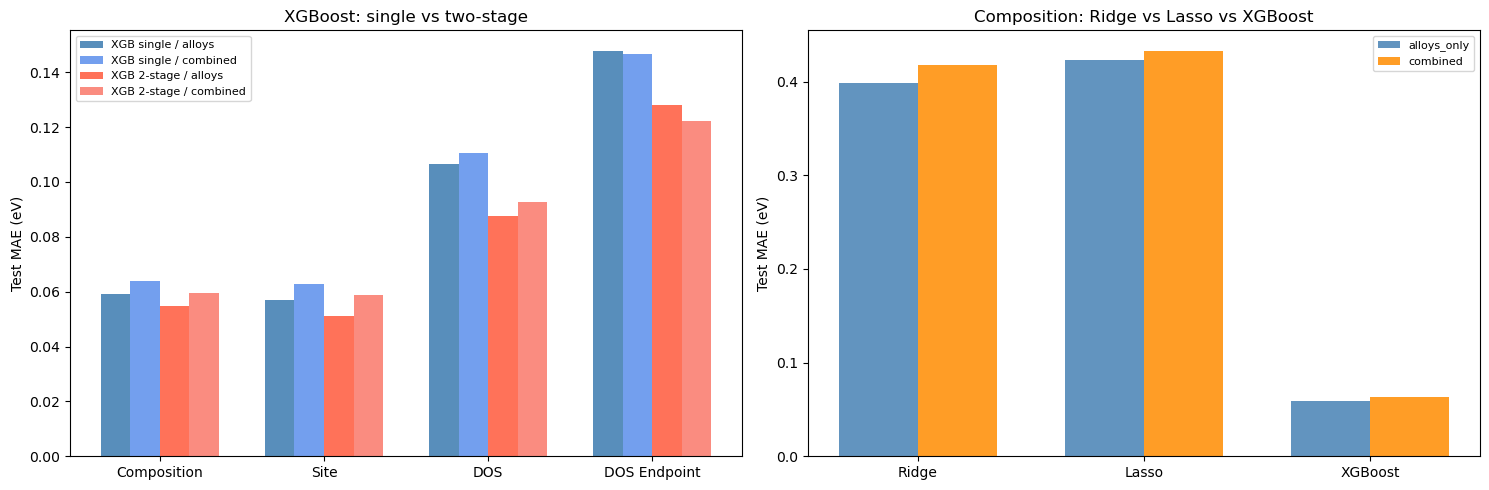

In [16]:
# --- Bar chart: test MAE by feature set, scope, and approach ---
feat_order   = ['Composition', 'Site', 'DOS', 'DOS Endpoint']
scope_styles = {'alloys_only': ('steelblue', 'solid'),
                'combined':    ('darkorange', 'dashed')}

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: XGBoost single vs two-stage across feature sets and scopes
ax = axes[0]
n_groups  = len(feat_order)
n_bars    = 4  # XGB_single×2_scopes + XGB_2stage×2_scopes
bar_w     = 0.18
x         = np.arange(n_groups)
bar_specs  = [
    ('single_regression', 'XGBoost',   'alloys_only', 'XGB single / alloys',   'steelblue',   0.9),
    ('single_regression', 'XGBoost',   'combined',    'XGB single / combined', 'cornflowerblue', 0.9),
    ('two_stage',         'XGB_2stage','alloys_only', 'XGB 2-stage / alloys',  'tomato',      0.9),
    ('two_stage',         'XGB_2stage','combined',    'XGB 2-stage / combined','salmon',      0.9),
]
for i, (approach, model, scope, label, color, alpha) in enumerate(bar_specs):
    vals = [
        results_df.loc[
            (results_df.feature_set==f) & (results_df.scope==scope) &
            (results_df.approach==approach) & (results_df.model==model), 'test_MAE'
        ].values[0]
        for f in feat_order
    ]
    ax.bar(x + i * bar_w, vals, bar_w, label=label, color=color, alpha=alpha)

ax.set_xticks(x + 1.5 * bar_w)
ax.set_xticklabels(feat_order)
ax.set_ylabel('Test MAE (eV)')
ax.set_title('XGBoost: single vs two-stage')
ax.legend(fontsize=8)
ax.set_ylim(0)

# Right: linear vs tree on Composition (the only feature set all three models share)
ax = axes[1]
comp_rows = results_df[
    (results_df.feature_set == 'Composition') &
    (results_df.approach == 'single_regression')
].copy()

model_order = ['Ridge', 'Lasso', 'XGBoost']
x2 = np.arange(len(model_order))
for i, (scope, color) in enumerate([('alloys_only','steelblue'), ('combined','darkorange')]):
    vals = [
        comp_rows.loc[(comp_rows.model==m) & (comp_rows.scope==scope), 'test_MAE'].values[0]
        for m in model_order
    ]
    ax.bar(x2 + i * 0.35, vals, 0.35, label=scope, color=color, alpha=0.85)

ax.set_xticks(x2 + 0.175)
ax.set_xticklabels(model_order)
ax.set_ylabel('Test MAE (eV)')
ax.set_title('Composition: Ridge vs Lasso vs XGBoost')
ax.legend(fontsize=8)
ax.set_ylim(0)

plt.tight_layout()
plt.show()

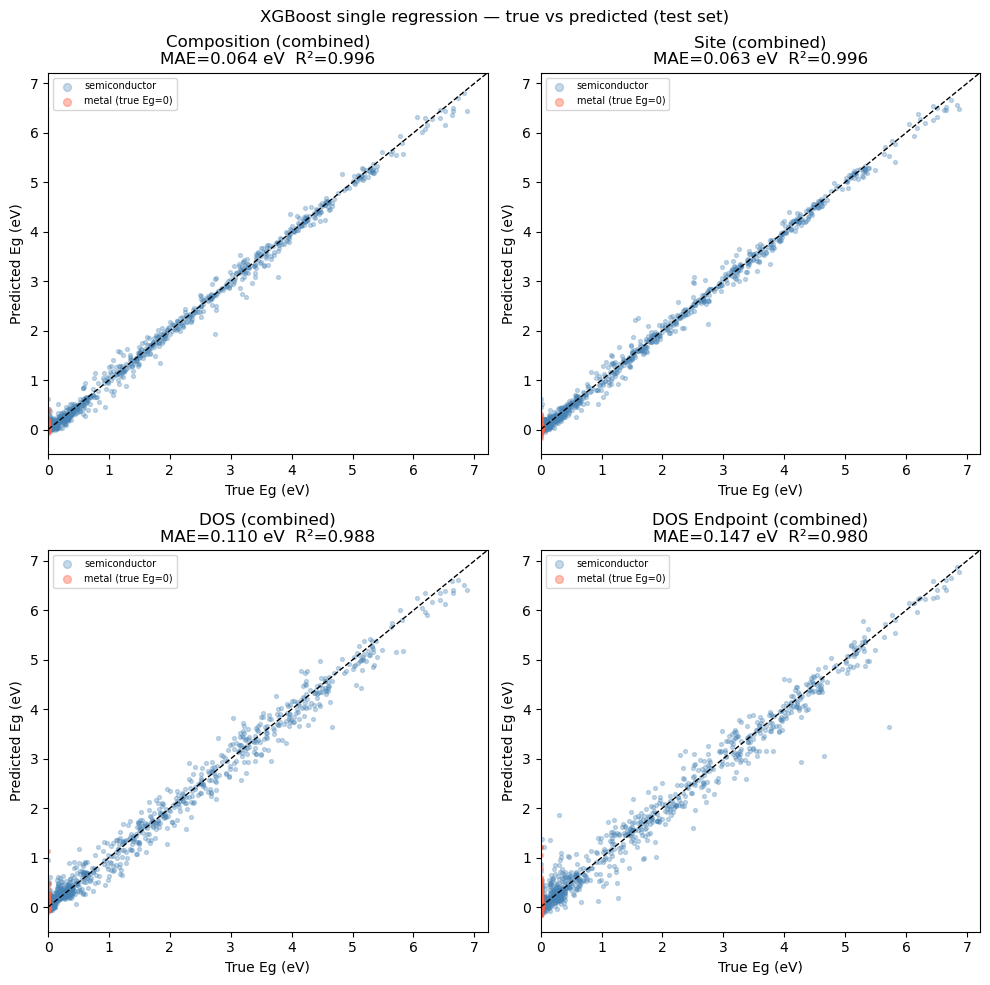

In [21]:
# Predicted vs actual scatter plots for XGBoost single regression across feature sets.
# Combined scope shown (includes pure phases as reference anchors).
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

for ax, feat_name in zip(axes.flat, feat_order):
    key = (feat_name, 'combined', 'single_regression', 'XGBoost')
    y_true, y_pred, _ = predictions[key]

    row = results_df[
        (results_df.feature_set == feat_name) &
        (results_df.scope == 'combined') &
        (results_df.model == 'XGBoost') &
        (results_df.approach == 'single_regression')
    ].iloc[0]

    # Colour by metallic vs semiconducting
    is_metal = (y_true == 0)
    ax.scatter(y_true[~is_metal], y_pred[~is_metal], alpha=0.3, s=8, color='steelblue', label='semiconductor')
    ax.scatter(y_true[is_metal],  y_pred[is_metal],  alpha=0.4, s=8, color='tomato',    label='metal (true Eg=0)')

    lim = max(y_true.max(), y_pred.max()) * 1.05
    ax.plot([0, lim], [0, lim], 'k--', linewidth=1)
    ax.set_xlim(0, lim);  ax.set_ylim(-0.5, lim)
    ax.set_xlabel('True Eg (eV)');  ax.set_ylabel('Predicted Eg (eV)')
    ax.set_title(f'{feat_name} (combined)\nMAE={row["test_MAE"]:.3f} eV  R²={row["test_R2"]:.3f}')
    ax.legend(fontsize=7, markerscale=2)

plt.suptitle('XGBoost single regression — true vs predicted (test set)', fontsize=12)
plt.tight_layout()
plt.show()

In [22]:
# Save results for reference without re-running.
results_df.drop(columns=['clf_accuracy','clf_F1_metal'], errors='ignore')
save_cols = ['feature_set','scope','approach','model','n_train','n_test',
             'train_MAE','test_MAE','test_RMSE','test_R2','train_R2',
             'clf_accuracy','clf_F1_metal']
results_df[save_cols].to_csv('baseline_results.csv', index=False)
print('Saved baseline_results.csv')
display(results_df[save_cols].sort_values('test_MAE').round(4).reset_index(drop=True))

Saved baseline_results.csv


,feature_set,scope,approach,model,n_train,n_test,train_MAE,test_MAE,test_RMSE,test_R2,train_R2,clf_accuracy,clf_F1_metal
0,Site,alloys_only,two_stage,XGB_2stage,4789,1203,0.0331,0.0510,0.0901,0.9968,0.9984,0.9368,0.9059
1,Composition,alloys_only,two_stage,XGB_2stage,4789,1203,0.0188,0.0547,0.0963,0.9964,0.9994,0.9401,0.9089
2,Site,alloys_only,single_regression,XGBoost,4789,1203,0.0403,0.0570,0.0890,0.9969,0.9984,NaN,NaN
3,Site,combined,two_stage,XGB_2stage,5210,1309,0.0373,0.0589,0.1034,0.9961,0.9982,0.9366,0.9008
4,Composition,alloys_only,single_regression,XGBoost,4789,1203,0.0248,0.0592,0.0955,0.9964,0.9994,NaN,NaN
5,Composition,combined,two_stage,XGB_2stage,5210,1309,0.0214,0.0595,0.1022,0.9962,0.9994,0.9381,0.9032
6,Site,combined,single_regression,XGBoost,5210,1309,0.0437,0.0629,0.1001,0.9963,0.9982,NaN,NaN
7,Composition,combined,single_regression,XGBoost,5210,1309,0.0281,0.0638,0.1035,0.9961,0.9993,NaN,NaN
8,DOS,alloys_only,two_stage,XGB_2stage,4789,1203,0.0349,0.0876,0.1538,0.9907,0.9984,0.9460,0.9202
9,DOS,combined,two_stage,XGB_2stage,5210,1309,0.0388,0.0927,0.1634,0.9903,0.9982,0.9358,0.9023


## 6. Feature Importance Analysis

Which features drive the predictions? This section extracts model internals to interpret the chemistry.

**Ridge coefficients** show the linear model's marginal effect: each coefficient represents the change in predicted Eg for a 1-unit increase in that feature (after standardization).

**XGBoost feature importance** shows which features are used most frequently in the tree splits. High importance = the feature partitions the data effectively to reduce prediction error. Directionality is implicit in splits: a split `if B1_MeltingT < 1850 then left` means high MeltingT (right branch) gets one prediction, low MeltingT (left branch) gets another.

**Caveat:** Importance ≠ truth. Correlated features can split importance between them. And importance tells you which features are *used*, not which are *causal*. But it's a good starting point for chemical interpretation.

In [23]:
# Ridge coefficients: linear model on Composition (alloys_only scope for cleaner signal)
scoped = SCOPES['alloys_only'](comp_df)
tr, te = make_split(scoped)

pipe = make_linear_pipeline()
X_tr_scaled = pipe.fit_transform(tr[COMP_COLS].values)

ridge = RidgeCV(alphas=ALPHA_GRID)
ridge.fit(X_tr_scaled, tr['Eg'].values)

coefs = ridge.coef_
coef_df = pd.DataFrame({
    'feature': COMP_COLS,
    'coefficient': coefs,
    'abs_coef': np.abs(coefs),
}).sort_values('abs_coef', ascending=False)

print('\n=== Ridge Coefficients (Composition, alloys-only) ===')
print('\nTop 15 features by |coefficient|:')
print(coef_df.head(15)[['feature', 'coefficient']].to_string(index=False))

print('\n\nInterpretation:')
print('Positive coef → feature increases Eg')
print('Negative coef → feature decreases Eg')
print('\nPhysical meaning:')
for _, row in coef_df.head(8).iterrows():
    feat = row['feature']
    coef = row['coefficient']
    direction = 'increases' if coef > 0 else 'decreases'
    magnitude = abs(coef)
    print(f"  {feat:50s} → {direction:9s} Eg (×{magnitude:.4f})")


=== Ridge Coefficients (Composition, alloys-only) ===

Top 15 features by |coefficient|:
                           feature  coefficient
            MagpieData mean Number   -17.066219
 MagpieData mean Electronegativity   -16.792138
      MagpieData mean AtomicWeight    15.240398
            MagpieData mean Column     6.715974
         MagpieData avg_dev Column     5.154723
   MagpieData mean MendeleevNumber     3.649750
       MagpieData avg_dev MeltingT     2.756374
MagpieData avg_dev MendeleevNumber     2.486034
               MagpieData mean Row     1.971675
         MagpieData mean NfValence     1.944220
         MagpieData maximum Number     1.656353
   MagpieData maximum AtomicWeight    -1.645949
       MagpieData mean GSvolume_pa    -1.579815
        MagpieData mean NdUnfilled    -1.561009
      MagpieData avg_dev NfValence    -1.533598


Interpretation:
Positive coef → feature increases Eg
Negative coef → feature decreases Eg

Physical meaning:
  MagpieData mean Number       

In [24]:
# XGBoost feature importance for best models per feature set
# Retrain to extract feature importances
importance_dict = {}

for feat_name, df, feat_cols in FEATURE_SETS:
    for scope_name, scope_fn in SCOPES.items():
        scoped = scope_fn(df)
        tr, te = make_split(scoped)
        
        X_tr = tr[feat_cols].values
        y_tr = tr['Eg'].values
        
        # Fit XGBoost
        model = XGBRegressor(**XGB_REG)
        model.fit(X_tr, y_tr)
        
        importances = model.feature_importances_
        importance_dict[(feat_name, scope_name)] = (importances, feat_cols)

print('=== XGBoost Feature Importances (single regression) ===\n')

for feat_name in ['Composition', 'Site', 'DOS']:
    importances, feat_cols = importance_dict[(feat_name, 'alloys_only')]
    
    imp_df = pd.DataFrame({
        'feature': feat_cols,
        'importance': importances,
    }).sort_values('importance', ascending=False)
    
    print(f'\n{feat_name} (alloys_only) — Top 12 features:')
    print(imp_df.head(12)[['feature', 'importance']].to_string(index=False))

=== XGBoost Feature Importances (single regression) ===


Composition (alloys_only) — Top 12 features:
                             feature  importance
         MagpieData maximum MeltingT    0.385010
           MagpieData range MeltingT    0.156735
         MagpieData range NdUnfilled    0.068291
         MagpieData avg_dev MeltingT    0.045517
           MagpieData mean NdValence    0.045289
        MagpieData maximum NdValence    0.039835
          MagpieData range NdValence    0.030001
       MagpieData maximum NdUnfilled    0.023867
MagpieData avg_dev Electronegativity    0.021549
            MagpieData mean NValence    0.021367
           MagpieData mean NUnfilled    0.016329
        MagpieData maximum NfValence    0.014722

Site (alloys_only) — Top 12 features:
             feature  importance
         B2_MeltingT    0.201663
         B1_MeltingT    0.184858
     B1_AtomicRadius    0.159427
     B2_AtomicRadius    0.096866
          X_MeltingT    0.044053
         B1_NValence   

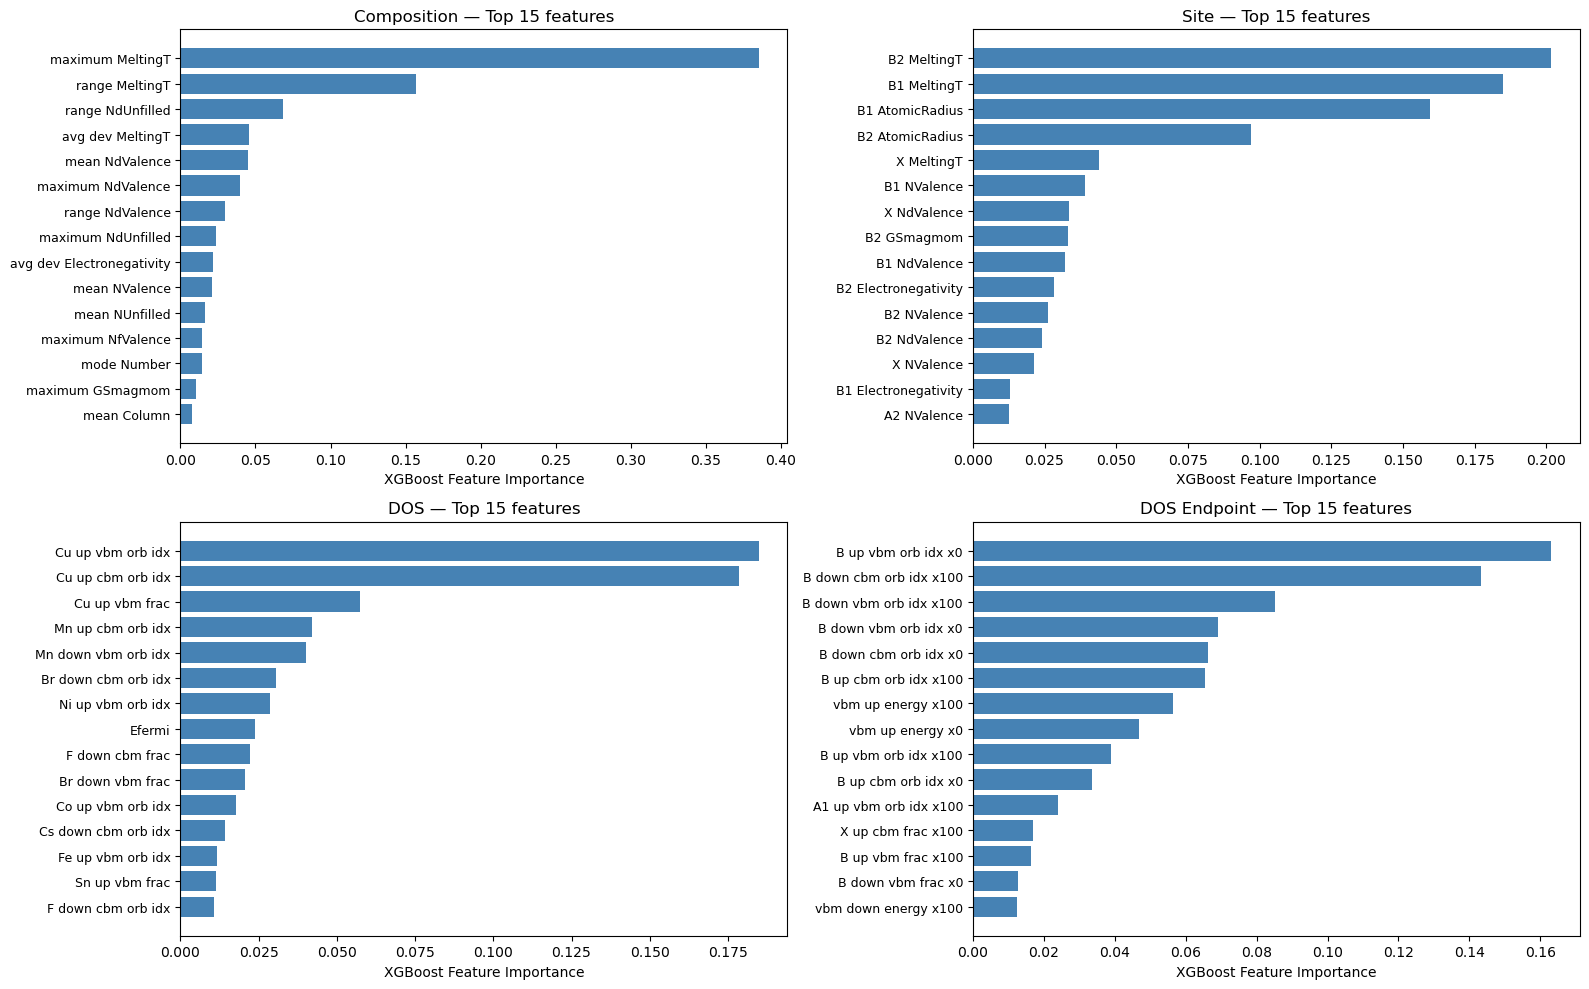

In [26]:
# Visualize top features for each feature set
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for ax, feat_name in zip(axes.flat, ['Composition', 'Site', 'DOS', 'DOS Endpoint']):
    importances, feat_cols = importance_dict[(feat_name, 'alloys_only')]
    
    imp_df = pd.DataFrame({
        'feature': feat_cols,
        'importance': importances,
    }).sort_values('importance', ascending=False).head(15)
    
    # Shorten feature names for readability
    short_names = [f.replace('MagpieData ', '').replace('_', ' ')[:40] for f in imp_df['feature']]
    
    ax.barh(range(len(imp_df)), imp_df['importance'].values, color='steelblue')
    ax.set_yticks(range(len(imp_df)))
    ax.set_yticklabels(short_names, fontsize=9)
    ax.set_xlabel('XGBoost Feature Importance')
    ax.set_title(f'{feat_name} — Top 15 features')
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

## Chemical Interpretation Guide

**Looking at Composition features (Ridge + XGBoost):**
- **Top Ridge coefficients**: Do they align with chemical intuition?
  - MeltingT ranks high? → Bond strength (cohesive energy) correlates with Eg.
  - Electronegativity? → Charge transfer, polarity effects.
  - Which site dominates (A, B, X)? → Tells you whether A-site size or B-site identity drives gaps.
- **MAGPIE statistics vs Site features**: If per-site features (Site matrix) outrank MAGPIE composition features, then element-specific chemistry matters more than stoichiometric averages.

**Looking at Site features (XGBoost):**
- **B1_MeltingT vs A1_MeltingT**: Which ranks higher? → B-site bond strength more important than A-site size?
- **B1_NdValence** (d-electron count): High importance for TM-containing materials? → Suggests transition metal chemistry drives band structure.
- **x_frac** (B-site mixing): Does it rank high? → Composition tuning is predictive; small variations in mixing fraction matter.
- **A2 features**: High importance despite 46% NaN? → The presence/absence of a second A-site element is informative.

**Looking at DOS features (XGBoost):**
- **Efermi rank**: High? → Electron filling (chemical potential) is predictive of Eg.
- **Element-specific DOS** (e.g., Pb_up_vbm_frac, I_up_cbm_frac): Which elements' orbital character dominates?
- **Rare-element features** (Li, Pt, Ag): Near-zero importance? → These elements absent in most compounds; their features carry no signal.
- **Spin-split features** (up/down orbital indices): Are spin effects important, or is single-spin sufficient?

**Comparing across feature sets—the key insights:**
- **If Site >> Composition**: Use detailed DFT-free elemental databases for screening; composition alone misses crucial physics.
- **If Composition ≈ Site**: Stoichiometric averages capture the essence; site-level detail adds little value; save engineering effort.
- **If DOS >> Site**: Need alloy DFT for accurate prediction; elemental proxies are insufficient. Define the Use Case B (endpoint DOS) strategy.

**Why this matters for YOUR next decision:**
The feature importance ranking directly informs which feature representations are worth engineering. If DOS dominates all other feature sets, then investing in endpoint DOS (Use Case B) is justified. If Composition alone gets 95% of the way there, focus on high-throughput composition screening instead.

In [ ]:
# to use model to predict novel material property, we need to generate a feature vector for the new material 
# that matches the features used in training.
# Then we use the feature vector as input to the model's predict method to get the predicted property value.
# e.g. model.predict(X) where X is the feature vector for the new material.
# Array should be 2D (n_samples, n_features) even if predicting for a single material
# e.g. X = np.array([[feat1, feat2, feat3, ...]]) 